<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Исследование структуры данных

1. Прочитайте данные с помощью библиотеки Pandas. Совет: перед чтением обратите внимание на разделитель внутри файла.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
path = '/content/drive/MyDrive/Colab Notebooks/dst-3.0_16_1_hh_database.csv'

In [4]:
df = pd.read_csv(path, encoding='utf-8', sep=';')

2. Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены. Ознакомьтесь с признаками и их структурой.

In [5]:
df.head(5)

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано
3,"Мужчина , 38 лет , родился 25 июня 1980",100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,"Саратов , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, удаленная работа",Опыт работы 18 лет 9 месяцев Август 2017 — Ап...,OpenSoft,Инженер-программист,Высшее образование 2002 Саратовский государст...,08.04.2019 14:23,Не указано
4,"Женщина , 26 лет , родилась 3 марта 1993",140000 руб.,Региональный менеджер по продажам,"Москва , не готова к переезду , готова к коман...",полная занятость,полный день,Опыт работы 5 лет 7 месяцев Региональный мене...,Мармелад,Менеджер по продажам,Высшее образование 2015 Кгу Психологии и педаг...,22.04.2019 10:32,Не указано


In [6]:
df.tail(5)

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
44739,"Мужчина , 30 лет , родился 17 января 1989",50000 руб.,"Финансист, аналитик, экономист, бухгалтер, мен...","Тверь , готов к переезду (Москва, Химки) , гот...",полная занятость,"полный день, удаленная работа","Опыт работы 7 лет 7 месяцев Финансист, аналит...","ООО ""IAS"" (независимый участник объединения Ru...",Руководитель субгруппы,Высшее образование 2015 Московский гуманитарн...,22.04.2019 12:32,Не указано
44740,"Мужчина , 27 лет , родился 5 марта 1992",39000 руб.,"Системный администратор, IT-специалист","Липецк , готов к переезду , готов к командировкам","проектная работа, частичная занятость, полная ...","удаленная работа, гибкий график, полный день, ...","Опыт работы 7 лет Системный администратор, IT...",ИП Пестрецов,Предприниматель,Высшее образование (Бакалавр) 2016 Воронежски...,22.04.2019 13:11,Не указано
44741,"Женщина , 48 лет , родилась 26 декабря 1970",40000 руб.,"Аналитик данных, Математик","Челябинск , готова к переезду , готова к редки...",полная занятость,"полный день, удаленная работа",Опыт работы 21 год 5 месяцев Январь 1998 — по...,"ОАО «ЧМК», Исследовательско-Технологический Це...",Начальник группы аналитики,Высшее образование 2000 Южно-Уральский госуда...,09.04.2019 05:07,Не указано
44742,"Мужчина , 24 года , родился 6 октября 1994",20000 руб.,Контент-менеджер,"Тамбов , не готов к переезду , не готов к кома...","частичная занятость, полная занятость",удаленная работа,Опыт работы 3 года 10 месяцев Контент-менедже...,IQ-Maxima,Менеджер проектов,Высшее образование 2015 Тамбовский государств...,26.04.2019 14:25,Имеется собственный автомобиль
44743,"Мужчина , 38 лет , родился 25 апреля 1980",120000 руб.,Руководитель проекта,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 15 лет 10 месяцев Руководитель пр...,ПАО ГК ТНС энерго,Руководитель отдела технической поддержки,Высшее образование 1997 Южно-Российский госуд...,05.07.2018 20:15,Не указано


3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.

4. Обратите внимание на информацию о числе непустых значений.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

5. Выведите основную статистическую информацию о столбцах.


In [8]:
df.describe()

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
count,44744,44744,44744,44744,44744,44744,44576,44743,44742,44744,44744,44744
unique,16003,690,14929,10063,38,47,44413,30214,16927,40148,18838,2
top,"Мужчина , 32 года , родился 17 сентября 1986",50000 руб.,Системный администратор,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,Индивидуальное предпринимательство / частная п...,Системный администратор,Высшее образование 2014 Тюменский Государствен...,07.05.2019 09:50,Не указано
freq,18,4064,3099,1261,30026,22727,3,935,2062,4,25,32268


# Преобразование данных

1. Начнем с простого - с признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)...
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота…
Нас будет интересовать только уровень образования.

Создайте с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".

Выполните преобразование, ответьте на контрольные вопросы и удалите признак "Образование и ВУЗ".

Совет: обратите внимание на структуру текста в столбце **"Образование и ВУЗ"**. Гарантируется, что текущий уровень образования соискателя всегда находится в первых 2ух слов и начинается с заглавной буквы. Воспользуйтесь этим.

*Совет: проверяйте полученные категории, например, с помощью метода unique()*


In [9]:
df['Образование'] = df['Образование и ВУЗ'].apply(
    lambda x: (
        np.nan if pd.isna(x) else
        ('неоконченное высшее' if str(x).strip().lower().startswith('неоконченное высшее') else
         'среднее специальное' if str(x).strip().lower().startswith('среднее специальное') else
         'высшее' if str(x).strip().lower().split()[0].startswith('высшее') else
         'среднее' if str(x).strip().lower().split()[0].startswith('среднее') else
         np.nan)
    )
)
df.drop(columns=['Образование и ВУЗ'], inplace=True)
df.head(5)

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Обновление резюме,Авто,Образование
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,16.04.2019 15:59,Имеется собственный автомобиль,неоконченное высшее
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",12.04.2019 08:42,Не указано,высшее
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,16.04.2019 08:35,Не указано,среднее специальное
3,"Мужчина , 38 лет , родился 25 июня 1980",100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,"Саратов , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, удаленная работа",Опыт работы 18 лет 9 месяцев Август 2017 — Ап...,OpenSoft,Инженер-программист,08.04.2019 14:23,Не указано,высшее
4,"Женщина , 26 лет , родилась 3 марта 1993",140000 руб.,Региональный менеджер по продажам,"Москва , не готова к переезду , готова к коман...",полная занятость,полный день,Опыт работы 5 лет 7 месяцев Региональный мене...,Мармелад,Менеджер по продажам,22.04.2019 10:32,Не указано,высшее


In [10]:
count = (df['Образование'] == 'среднее').sum()
print(count)

559


2. Теперь нас интересует столбец **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979
* Женщина , 21 год , родилась 13 января 2000
Как вы понимаете, нам необходимо выделить каждый параметр в отдельный столбец.

Создайте два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина.
* Признак возраста должен быть представлен целыми числами.

Выполните преобразование, ответьте на контрольные вопросы и удалите признак **"Пол, возраст"** из таблицы.

*Совет: обратите внимание на структуру текста в столбце, в части на то, как разделены параметры пола, возраста и даты рождения между собой - символом ' , '.
Гарантируется, что структура одинакова для всех строк в таблице. Вы можете воспользоваться этим.*


In [11]:
df[['Пол_исх', 'Возраст_исх', 'Дата_рождения']] = df['Пол, возраст'].str.split(' , ', expand=True)
df['Пол'] = df['Пол_исх'].map({
    'Мужчина': 'М',
    'Женщина': 'Ж'
})
df['Возраст'] = df['Возраст_исх'].str.extract(r'(\d+)').astype(int)
df.drop(columns=['Пол, возраст', 'Пол_исх', 'Возраст_исх', 'Дата_рождения'], inplace=True)

In [12]:
count_women = (df['Пол'] == 'Ж').sum()
total_count = len(df)
percent_women = round((count_women / total_count) * 100, 2)
print(f"Процент женских резюме: {percent_women}%")

Процент женских резюме: 19.07%


In [13]:
average_age = df['Возраст'].mean()
average_age_rounded = round(average_age, 1)
print(f"Средний возраст соискателей: {average_age_rounded}")

Средний возраст соискателей: 32.2


3. Следующим этапом преобразуем признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**.

Из столбца нам необходимо выделить общий опыт работы соискателя в месяцах, новый признак назовем "Опыт работы (месяц)"

Для начала обсудим условия решения задачи:
* Во-первых, в данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть (функция-преобразование возвращает NaN)
* Во-вторых, в данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN (функция-преобразование возвращает NaN)
* В-третьих, нас не интересует информация, которая описывается после указания опыта работы (периоды работы в различных компаниях)
* В-четвертых, у нас есть проблема: опыт работы может быть представлен только в годах или только месяцах. Например, можно встретить следующие варианты:
    * Опыт работы 3 года 2 месяца…
    * Опыт работы 4 года…
    * Опыт работы 11 месяцев…
    * Учитывайте эту особенность в вашем коде

Учитывайте эту особенность в вашем коде

В результате преобразования у вас должен получиться столбец, содержащий информацию о том, сколько месяцев проработал соискатель.
Выполните преобразование, ответьте на контрольные вопросы и удалите столбец **"Опыт работы"** из таблицы.


In [14]:
def get_experience(arg):
    if arg is np.nan or arg == 'Не указано':
        return None
    year_words=['год', 'года', 'лет']
    month_words=['месяц', 'месяца', 'месяцев']
    arg_splitted = arg.split(' ')[:7]
    years = 0
    months = 0
    for index, item in enumerate (arg_splitted):
        if item in year_words:
            years = int(arg_splitted[index-1])
        if item in month_words:
            months = int(arg_splitted[index-1])
    return int(years*12 + months)
df['Опыт работы (месяц)'] = df['Опыт работы'].apply(get_experience)
df = df.drop('Опыт работы', axis=1)

In [15]:
median_experience = df['Опыт работы (месяц)'].median()
print(f"Медианный опыт работы: {median_experience}")

Медианный опыт работы: 100.0


4. Хорошо идем! Следующий на очереди признак "Город, переезд, командировки". Информация в нем представлена в следующем виде: **<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>**. В скобках указаны необязательные параметры строки. Например, можно встретить следующие варианты:

* Москва , не готов к переезду , готов к командировкам
* Москва , м. Беломорская , не готов к переезду, не готов к командировкам
* Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам

Создадим отдельные признаки **"Город"**, **"Готовность к переезду"**, **"Готовность к командировкам"**. При этом важно учесть:

* Признак **"Город"** должен содержать только 4 категории: "Москва", "Санкт-Петербург" и "город-миллионник" (их список ниже), остальные обозначьте как "другие".

    Список городов-миллионников:
    
   <code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
    </code>
    Инфорация о метро, рядом с которым проживает соискатель нас не интересует.
* Признак **"Готовность к переезду"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к переезду в признаке "Город, переезд, командировки". Например:
    * … , готов к переезду , …
    * … , не готова к переезду , …
    * … , готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)
    * … , хочу переехать (США) , …
    
    Нас интересует только сам факт возможности или желания переезда.
* Признак **"Готовность к командировкам"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к командировкам в признаке "Город, переезд, командировки". Например:
    * … , готов к командировкам , …
    * … , готова к редким командировкам , …
    * … , не готов к командировкам , …
    
    Нас интересует только сам факт готовности к командировке.
    
    Еще один важный факт: при выгрузки данных у некоторых соискателей "потерялась" информация о готовности к командировкам. Давайте по умолчанию будем считать, что такие соискатели не готовы к командировкам.
    
Выполните преобразования и удалите столбец **"Город, переезд, командировки"** из таблицы.

*Совет: обратите внимание на то, что структура текста может меняться в зависимости от указания ближайшего метро. Учите это, если будете использовать порядок слов в своей программе.*


In [16]:
def get_city(arg):
    million_cities = ['Новосибирск', 'Екатеринбург', 'Нижний Новгород',
                      'Казань', 'Челябинск', 'Омск', 'Самара', 'Ростов-на-Дону',
                      'Уфа', 'Красноярск', 'Пермь', 'Воронеж', 'Волгоград'
                     ]
    city = arg.split(' , ')[0]
    if (city == 'Москва') or (city == 'Санкт-Петербург'):
        return city
    elif city in million_cities:
        return 'город миллионник'
    else:
        return 'другие'

def get_ready_to_move(arg):
    if ('не готов к переезду' in arg) or ('не готова к переезду' in arg):
        return False
    elif 'хочу' in arg:
        return True
    else:
        return True

def get_ready_for_bisiness_trips(arg):
    if ('командировка' in arg):
        if ('не готов к командировкам' in arg) or('не готова к командировкам' in arg):
            return False
        else:

            return True
    else:
        return False

df['Город'] = df['Город, переезд, командировки'].apply(get_city)
df['Готовность к переезду'] = df['Город, переезд, командировки'].apply(get_ready_to_move)
df['Готовность к командировкам'] = df['Город, переезд, командировки'].apply(get_ready_for_bisiness_trips)
df = df.drop('Город, переезд, командировки', axis=1)

In [17]:
spb_count = df[df['Город'] == 'Санкт-Петербург'].shape[0]
total_count = df.shape[0]
percentage_spb = (spb_count / total_count) * 100
percentage_spb_rounded = round(percentage_spb)
print(f"Процент соискателей из Санкт-Петербурга: {percentage_spb_rounded}%")

Процент соискателей из Санкт-Петербурга: 11%


In [18]:
filtered = df[
    (df['Готовность к переезду'] == True) &
    (df['Готовность к командировкам'] == True)
]
count_both_ready = filtered.shape[0]
total_count = df.shape[0]
percentage = round((count_both_ready / total_count) * 100)
print(f"Процент соискателей, готовых одновременно к переезду и командировкам: {percentage}%")

Процент соискателей, готовых одновременно к переезду и командировкам: 32%


5. Рассмотрим поближе признаки **"Занятость"** и **"График"**. Сейчас признаки представляют собой набор категорий желаемой занятости (полная занятость, частичная занятость, проектная работа, волонтерство, стажировка) и желаемого графика работы (полный день, сменный график, гибкий график, удаленная работа, вахтовый метод).
На сайте hh.ru соискатель может указывать различные комбинации данных категорий, например:
* полная занятость, частичная занятость
* частичная занятость, проектная работа, волонтерство
* полный день, удаленная работа
* вахтовый метод, гибкий график, удаленная работа, полная занятость

Такой вариант признаков имеет множество различных комбинаций, а значит множество уникальных значений, что мешает анализу. Нужно это исправить!

Давайте создадим признаки-мигалки для каждой категории: если категория присутствует в списке желаемых соискателем, то в столбце на месте строки рассматриваемого соискателя ставится True, иначе - False.

Такой метод преобразования категориальных признаков называется One Hot Encoding и его схема представлена на рисунке ниже:
<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/ohe.jpg>
Выполните данное преобразование для признаков "Занятость" и "График", ответьте на контрольные вопросы, после чего удалите их из таблицы

In [19]:
occupations = [
    "полная занятость", "частичная занятость", "проектная работа", "волонтерство", "стажировка"
]
schedules = [
    "полный день", "сменный график", "гибкий график", "удаленная работа", "вахтовый метод"
]

def one_hot_encode_column(series, categories):
    for cat in categories:
        series_cat = series.fillna("").str.lower().str.contains(cat)
        yield (cat, series_cat)
for cat, bool_col in one_hot_encode_column(df['Занятость'], occupations):
    df[cat] = bool_col

for cat, bool_col in one_hot_encode_column(df['График'], schedules):
    df[cat] = bool_col

In [20]:
count = (df['проектная работа'] & df['волонтерство']).sum()
print(count)

436


In [21]:
count = (df['вахтовый метод'] & df['гибкий график']).sum()
print(count)

2311


In [22]:
df = df.drop(['Занятость', 'График'], axis=1)


6. (2 балла) Наконец, мы добрались до самого главного и самого важного - признака заработной платы **"ЗП"**.
В чем наша беда? В том, что помимо желаемой заработной платы соискатель указывает валюту, в которой он бы хотел ее получать, например:
* 30000 руб.
* 50000 грн.
* 550 USD

Нам бы хотелось видеть заработную плату в единой валюте, например, в рублях. Возникает вопрос, а где взять курс валют по отношению к рублю?

На самом деле язык Python имеет в арсенале огромное количество возможностей получения данной информации, от обращения к API Центробанка, до использования специальных библиотек, например pycbrf. Однако, это не тема нашего проекта.

Поэтому мы пойдем в лоб: обратимся к специальным интернет-ресурсам для получения данных о курсе в виде текстовых файлов. Например, MDF.RU, данный ресурс позволяет удобно экспортировать данные о курсах различных валют и акций за указанные периоды в виде csv файлов. Мы уже сделали выгрузку курсов валют, которые встречаются в наших данных за период с 29.12.2017 по 05.12.2019. Скачать ее вы можете **на платформе**

Создайте новый DataFrame из полученного файла. В полученной таблице нас будут интересовать столбцы:
* "currency" - наименование валюты в ISO кодировке,
* "date" - дата,
* "proportion" - пропорция,
* "close" - цена закрытия (последний зафиксированный курс валюты на указанный день).


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге.
Воспользуйтесь этой информацией в ваших преобразованиях.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>


Осталось только понять, откуда брать дату, по которой определяется курс? А вот же она - в признаке **"Обновление резюме"**, в нем содержится дата и время, когда соискатель выложил текущий вариант своего резюме. Нас интересует только дата, по ней бы и будем сопоставлять курсы валют.

Теперь у нас есть вся необходимая информация для того, чтобы создать признак "ЗП (руб)" - заработная плата в рублях.

После ответа на контрольные вопросы удалите исходный столбец заработной платы "ЗП" и все промежуточные столбцы, если вы их создавали.

Итак, давайте обсудим возможный алгоритм преобразования:
1. Перевести признак "Обновление резюме" из таблицы с резюме в формат datetime и достать из него дату. В тот же формат привести признак "date" из таблицы с валютами.
2. Выделить из столбца "ЗП" сумму желаемой заработной платы и наименование валюты, в которой она исчисляется. Наименование валюты перевести в стандарт ISO согласно с таблицей выше.
3. Присоединить к таблице с резюме таблицу с курсами по столбцам с датой и названием валюты (подумайте, какой тип объединения надо выбрать, чтобы в таблице с резюме сохранились данные о заработной плате, изначально представленной в рублях). Значение close для рубля заполнить единицей 1 (курс рубля самого к себе)
4. Умножить сумму желаемой заработной платы на присоединенный курс валюты (close) и разделить на пропорцию (обратите внимание на пропуски после объединения в этих столбцах), результат занести в новый столбец "ЗП (руб)".


In [23]:
path_2 = '/content/drive/MyDrive/Colab Notebooks/ExchangeRates.csv'
df_2 = pd.read_csv(path_2, encoding='utf-8', sep=',')
columns_needed = ['currency', 'date', 'proportion', 'close']
rates = df_2[columns_needed]

In [24]:
def get_salary_num(arg):
    salary =float(arg.split(' ')[0])
    return salary

def get_salary_currency(arg):
    currency_dict = {
        'USD': 'USD', 'KZT': 'KZT',
        'грн': 'UAH', 'белруб': 'BYN',
        'EUR': 'EUR', 'KGS': 'KGS',
        'сум': 'UZS', 'AZN': 'AZN'
    }
    curr = arg.split(' ')[1].replace('.', '')
    if curr == 'руб':
        return 'RUB'
    else:
        return currency_dict[curr]

#rates = pd.read_csv('data/ExchangeRates.csv')
rates['date'] = pd.to_datetime(rates['date'], dayfirst=True).dt.date
df['Обновление резюме'] = pd.to_datetime(df['Обновление резюме'], dayfirst=True).dt.date
df['ЗП (tmp)'] = df['ЗП'].apply(get_salary_num)
df['Курс (tmp)'] = df['ЗП'].apply(get_salary_currency)
merged = df.merge(
    rates,
    left_on=['Курс (tmp)', 'Обновление резюме'],
    right_on=['currency', 'date',],
    how='left'
)
merged['close'] = merged['close'].fillna(1)
merged['proportion'] = merged['proportion'].fillna(1)
df['ЗП (руб)'] = merged['close'] * merged['ЗП (tmp)'] / merged['proportion']
df = df.drop(['ЗП', 'ЗП (tmp)', 'Курс (tmp)'], axis=1)

/tmp/ipython-input-3053066458.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rates['date'] = pd.to_datetime(rates['date'], dayfirst=True).dt.date
/tmp/ipython-input-3053066458.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rates['date'] = pd.to_datetime(rates['date'], dayfirst=True).dt.date


In [25]:
print(round(df['ЗП (руб)'].median()/1000))

59


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44744 non-null  object 
 1   Последнее/нынешнее место работы  44743 non-null  object 
 2   Последняя/нынешняя должность     44742 non-null  object 
 3   Обновление резюме                44744 non-null  object 
 4   Авто                             44744 non-null  object 
 5   Образование                      44744 non-null  object 
 6   Пол                              44744 non-null  object 
 7   Возраст                          44744 non-null  int64  
 8   Опыт работы (месяц)              44574 non-null  float64
 9   Город                            44744 non-null  object 
 10  Готовность к переезду            44744 non-null  bool   
 11  Готовность к командировкам       44744 non-null  bool   
 12  полная занятость  

# Исследование зависимостей в данных

1. Постройте распределение признака **"Возраст"**. Опишите распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей? Есть ли аномалии для признака возраста, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

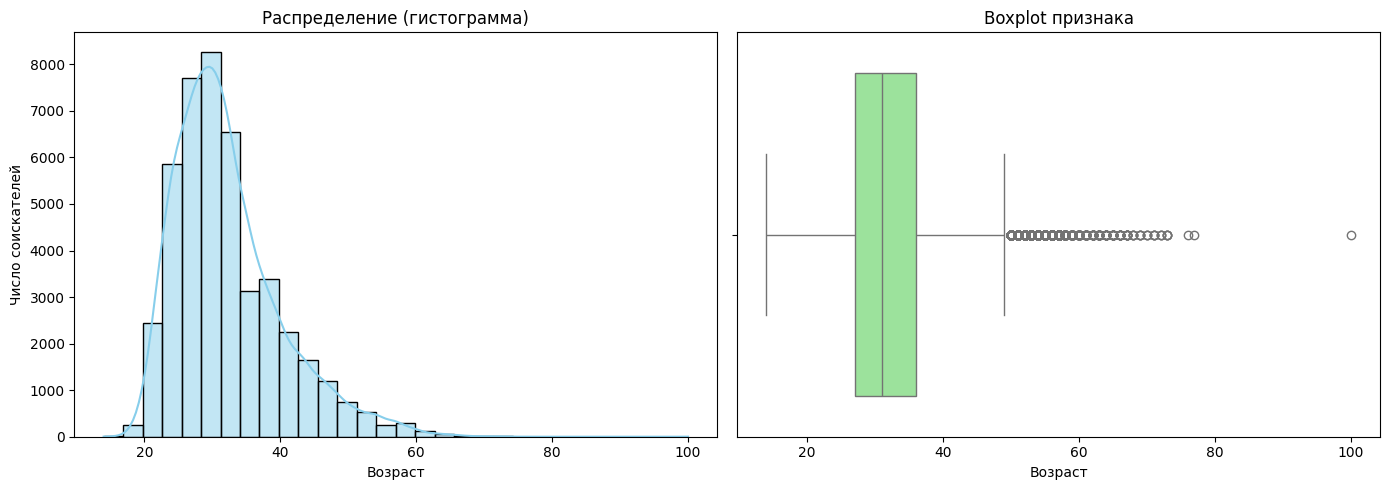

Мода: 30
Минимальный возраст: 14
Максимальный возраст: 100
Основной интервал (25%-75%): 27–36
Аномальные значения: [np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(76), np.int64(77), np.int64(100)]


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Возраст'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Распределение (гистограмма)')
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Число соискателей')

sns.boxplot(x=df['Возраст'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot признака')
axes[1].set_xlabel('Возраст')

plt.tight_layout()
plt.show()

mode_age = df['Возраст'].mode().iloc[0]
min_age = df['Возраст'].min()
max_age = df['Возраст'].max()
q1 = df['Возраст'].quantile(0.25)
q3 = df['Возраст'].quantile(0.75)

print(f"Мода: {mode_age}")
print(f"Минимальный возраст: {min_age}")
print(f"Максимальный возраст: {max_age}")
print(f"Основной интервал (25%-75%): {int(q1)}–{int(q3)}")

outliers = df[(df['Возраст'] < 14) | (df['Возраст'] > 65)]['Возраст'].unique()
print(f"Аномальные значения: {sorted(outliers)}")

Распределение признака «Возраст» соискателей выглядит следующим образом:
- Мода — наиболее часто встречающееся значение: 30 лет.
- Минимальный возраст — 14 лет.
- Максимальный возраст — 100 лет.
- Основной интервал (25%-75%) — возраст большинства соискателей находится в диапазоне от 27 до 36 лет.
- На гистограмме наблюдается выраженный правосторонний (положительный) сдвиг: молодых существенно больше, с увеличением возраста число соискателей быстро снижается.
- Аномалии: к аномальным можно отнести значения старше 65 лет — это кандидаты в возрасте 66 лет и старше, а также максимально редко встречающееся значение 100 лет:
- 66, 67, 68, 69, 70, 71, 72, 73, 76, 77, 100
На boxplot это проявляется как отдельные точки-выбросы справа от основного "ящика".

Большинство соискателей — люди в возрасте от 27 до 36 лет, пик частоты — 30 лет. За пределами 65–70 лет количество анкет быстро уменьшается, а значения ближе к 100 годам можно считать аномальными — скорее всего, это ошибки заполнения.


2. Постройте распределение признака **"Опыт работы (месяц)"**. Опишите данное распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей? Есть ли аномалии для признака опыта работы, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

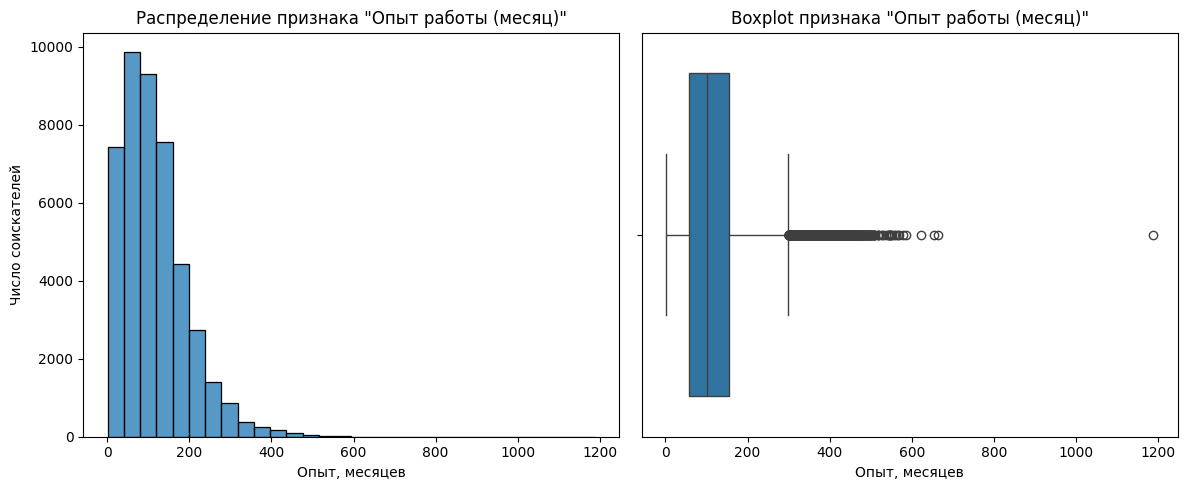

Мода: 81.0
Минимальный опыт работы (месяцев): 1.0
Максимальный опыт работы (месяцев): 1188.0
Основной интервал (25%-75% кв.) — от 57 до 154 месяцев.
Аномалии (по критерию boxplot): [np.float64(300.0), np.float64(301.0), np.float64(302.0), np.float64(303.0), np.float64(304.0), np.float64(305.0), np.float64(306.0), np.float64(307.0), np.float64(308.0), np.float64(309.0), np.float64(310.0), np.float64(311.0), np.float64(312.0), np.float64(313.0), np.float64(314.0), np.float64(315.0), np.float64(316.0), np.float64(317.0), np.float64(318.0), np.float64(319.0), np.float64(320.0), np.float64(321.0), np.float64(322.0), np.float64(323.0), np.float64(324.0), np.float64(325.0), np.float64(326.0), np.float64(327.0), np.float64(328.0), np.float64(329.0), np.float64(330.0), np.float64(331.0), np.float64(332.0), np.float64(333.0), np.float64(334.0), np.float64(335.0), np.float64(336.0), np.float64(337.0), np.float64(338.0), np.float64(339.0), np.float64(340.0), np.float64(341.0), np.float64(342.0), n

In [28]:
df['Опыт работы (месяц)'] = pd.to_numeric(df['Опыт работы (месяц)'], errors='coerce')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Опыт работы (месяц)'].dropna(), bins=30)
plt.title('Распределение признака "Опыт работы (месяц)"')
plt.xlabel('Опыт, месяцев')
plt.ylabel('Число соискателей')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Опыт работы (месяц)'])
plt.title('Boxplot признака "Опыт работы (месяц)"')
plt.xlabel('Опыт, месяцев')

plt.tight_layout()
plt.show()

mode_exp = df['Опыт работы (месяц)'].mode(dropna=True)[0]
min_exp = df['Опыт работы (месяц)'].min()
max_exp = df['Опыт работы (месяц)'].max()
q1 = df['Опыт работы (месяц)'].quantile(0.25)
q3 = df['Опыт работы (месяц)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df[(df['Опыт работы (месяц)'] < lower_bound) | (df['Опыт работы (месяц)'] > upper_bound)]['Опыт работы (месяц)'].unique()

print(f'''Мода: {mode_exp}
Минимальный опыт работы (месяцев): {min_exp}
Максимальный опыт работы (месяцев): {max_exp}
Основной интервал (25%-75% кв.) — от {int(q1)} до {int(q3)} месяцев.
Аномалии (по критерию boxplot): {sorted(outliers)}
''')

Мода равна 81 месяц — то есть, чаще всего среди соискателей встречается именно такой опыт работы.
Предельные значения признака:
- Минимальное значение: 1 месяц  
- Максимальное значение: 1188 месяцев (99 лет)

Опыт работы большинства соискателей лежит в диапазоне от 57 до 154 месяцев (это 25–75 перцентили, то есть 4 года 9 месяцев — 12 лет 10 месяцев).

На боксплоте видно множество выбросов справа. Значения значительно превышающие 154 месяца можно считать аномалиями, особенно выделяются опыты более 400–500 месяцев (33–41 года) и, конечно, значение 1188 месяцев (99 лет) — это практически невозможно в реальной жизни, такой стаж явно ошибочен.

3. Постройте распределение признака **"ЗП (руб)"**. Опишите данное распределение, отвечая на следующие вопросы: каковы предельные значения признака, в каком примерном интервале находится заработная плата большинства соискателей? Есть ли аномалии для признака возраста? Обратите внимание на гигантские размеры желаемой заработной платы.
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*


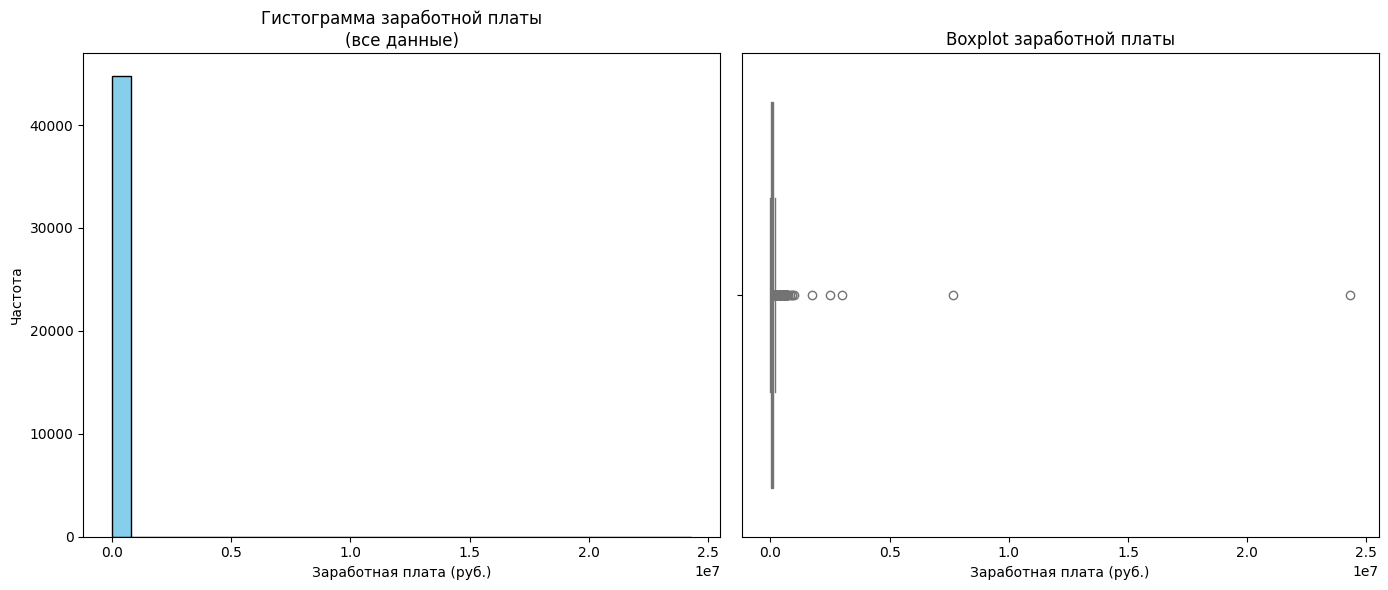

Предельные значения: от 1 до 24,304,876 руб.
Большинство соискателей (50%) указывают ЗП в интервале [37,082 – 95,000] руб.
Обнаружены аномально высокие/низкие значения (выбросы): 2781 наблюдений.
Границы аномалий: ЗП < -49,795 руб. или > 181,877 руб.
Значения выбросов: [182425.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185000.0, 185437.5, 186000.0, 187000.0, 187000.0, 187000.31999999998, 187099.59, 188501.4, 188968.00999999998, 189969.25, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.0, 190000.

In [29]:
min_salary = df['ЗП (руб)'].min()
max_salary = df['ЗП (руб)'].max()
q1 = df['ЗП (руб)'].quantile(0.25)
q3 = df['ЗП (руб)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Выбросы
outliers = df[(df['ЗП (руб)'] < lower_bound) | (df['ЗП (руб)'] > upper_bound)]

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Гистограмма (все значения)
axes[0].hist(df['ЗП (руб)'].dropna(), bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Гистограмма заработной платы\n(все данные)')
axes[0].set_xlabel('Заработная плата (руб.)')
axes[0].set_ylabel('Частота')

# Коробчатая диаграмма
sns.boxplot(x=df['ЗП (руб)'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot заработной платы')
axes[1].set_xlabel('Заработная плата (руб.)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Вывод статистики и анализа
print(f"Предельные значения: от {min_salary:,.0f} до {max_salary:,.0f} руб.")
print(f"Большинство соискателей (50%) указывают ЗП в интервале [{q1:,.0f} – {q3:,.0f}] руб.")
if len(outliers) > 0:
    print(f"Обнаружены аномально высокие/низкие значения (выбросы): {len(outliers)} наблюдений.")
    print(f"Границы аномалий: ЗП < {lower_bound:,.0f} руб. или > {upper_bound:,.0f} руб.")
    print(f"Значения выбросов: {sorted(outliers['ЗП (руб)'].dropna().tolist())}")
else:
    print("Аномалий (выбросов) не обнаружено.")

Минимальная заработная плата: 1 рубль, максимальная заработная плата: 24 304 876 рублей.
Основная масса (межквартильный размах): 37 082 – 95 000 рублей. В этом диапазоне лежит половина всех значений (50%), то есть столько указывает большинство соискателей.

Количество выбросов: 2 781 наблюдение — это значения, которые вышли за пределы интервала –49 795; 181 877 рублей (расчитано по стандартному правилу 1.5×IQR).
Особенно очевидны аномально высокие значения: до 24 млн рублей (смещают масштаб графиков, из-за чего основная масса значений сжимается к нулю на гистограмме и boxplot).
Среди выбросов — повторяющиеся значения 185 000 рублей и выше, а также экстремальные значения выше 1 миллиона рублей. Это может быть ошибкой ввода или редкими случаями.

Распределение очень скошено вправо — большинство зарплат лежит в пределах 37–95 тысяч, в то время как встречаются единичные экстремальные запросы в миллионы.
Наблюдается большое количество выбросов, причём значительная их часть связана с завышенными ожиданиями или ошибками в данных.

4. Постройте диаграмму, которая показывает зависимость **медианной** желаемой заработной платы (**"ЗП (руб)"**) от уровня образования (**"Образование"**). Используйте для диаграммы данные о резюме, где желаемая заработная плата меньше 1 млн рублей.
*Сделайте выводы по представленной диаграмме: для каких уровней образования наблюдаются наибольшие и наименьшие уровни желаемой заработной платы? Как вы считаете, важен ли признак уровня образования при прогнозировании заработной платы?*

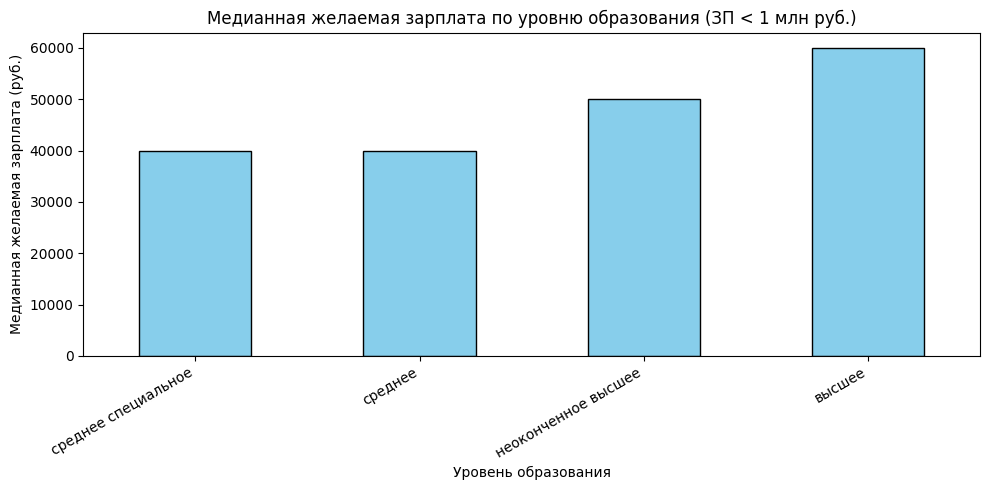

In [30]:
df_filtered = df[df['ЗП (руб)'] < 1000000]

median_salary_by_education = df_filtered.groupby('Образование')['ЗП (руб)'].median().sort_values()

plt.figure(figsize=(10, 5))
median_salary_by_education.plot(kind='bar', color='skyblue', edgecolor='black')
plt.ylabel('Медианная желаемая зарплата (руб.)')
plt.xlabel('Уровень образования')
plt.title('Медианная желаемая зарплата по уровню образования (ЗП < 1 млн руб.)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Наибольшая медианная желаемая зарплата наблюдается у соискателей с высшим образованием — это самый высокий столбец на диаграмме.

Наименьшие медианные зарплатные ожидания у соискателей с средним и средним специальным образованием — их значения примерно одинаковы и самые низкие.

Соискатели с незаконченным высшим образованием занимают промежуточное положение: их медианные запросы выше, чем у соискателей со средним образованием, но ниже, чем у обладателей высшего образования.

Уровень образования важен для прогнозирования желаемой заработной платы. Диаграмма наглядно показывает прямую зависимость: чем выше образование, тем выше медианная зарплата, которую ожидают кандидаты. Это значит, что уровень образования — важный показатель при моделировании и прогнозировании заработной платы.

5. Постройте диаграмму, которая показывает распределение желаемой заработной платы (**"ЗП (руб)"**) в зависимости от города (**"Город"**). Используйте для диаграммы данные о резюме, где желая заработная плата меньше 1 млн рублей.
*Сделайте выводы по полученной диаграмме: как соотносятся медианные уровни желаемой заработной платы и их размах в городах? Как вы считаете, важен ли признак города при прогнозировании заработной платы?*

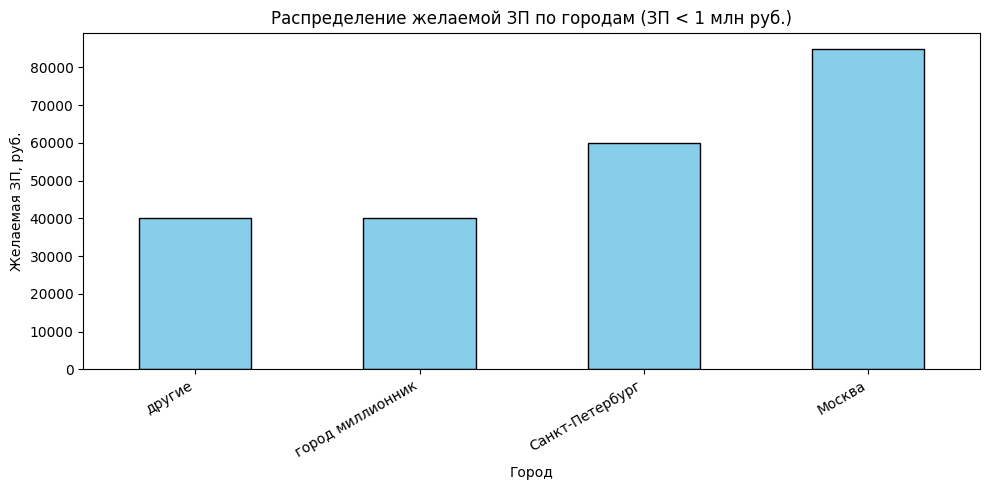

In [31]:
df_filtered_2 = df[df['ЗП (руб)'] < 1000000]

median_salary_by_education = df_filtered_2.groupby('Город')['ЗП (руб)'].median().sort_values()

plt.figure(figsize=(10, 5))
median_salary_by_education.plot(kind='bar', color='skyblue', edgecolor='black')
plt.ylabel('Желаемая ЗП, руб.')
plt.xlabel('Город')
plt.title('Распределение желаемой ЗП по городам (ЗП < 1 млн руб.)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [32]:
idx_max = df_filtered_2['ЗП (руб)'].idxmax()
max_city = df_filtered_2.loc[idx_max, 'Город']
max_salary = df_filtered_2.loc[idx_max, 'ЗП (руб)']

print(f'Максимальная желаемая ЗП: {max_salary:,.0f} руб.')
print(f'Город: {max_city}')

Максимальная желаемая ЗП: 923,983 руб.
Город: другие


Медианные уровни желаемой заработной платы сильно различаются по городам:  
- Самые высокие медианные значения — в Москве (более 80 000 руб.)  
- Далее идёт Санкт-Петербург (около 60 000 руб.)
- В городах-миллионниках и других городах медианная зарплата существенно ниже (порядка 40 000–45 000 руб.)

Размах (разброс) зарплат также различается:  
- В Москве размах желаемых зарплат наиболее выражен — это может свидетельствовать о больших различиях в запросах соискателей.
- В Санкт-Петербурге диапазон чуть меньше, но тоже заметен.
- В городах-миллионниках и остальных городах разброс относительно небольшой, что указывает на более согласованные ожидания.

Признак «город» явно оказывает влияние на уровень желаемой заработной платы. Различия между регионами значительны, особенно между Москвой/Санкт-Петербургом и остальными городами. Это связано с разным уровнем жизни, экономическим развитием, количеством вакансий, политикой локальных компаний и т.д.


6. Постройте **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. Проанализируйте график, сравнив уровень заработной платы в категориях.

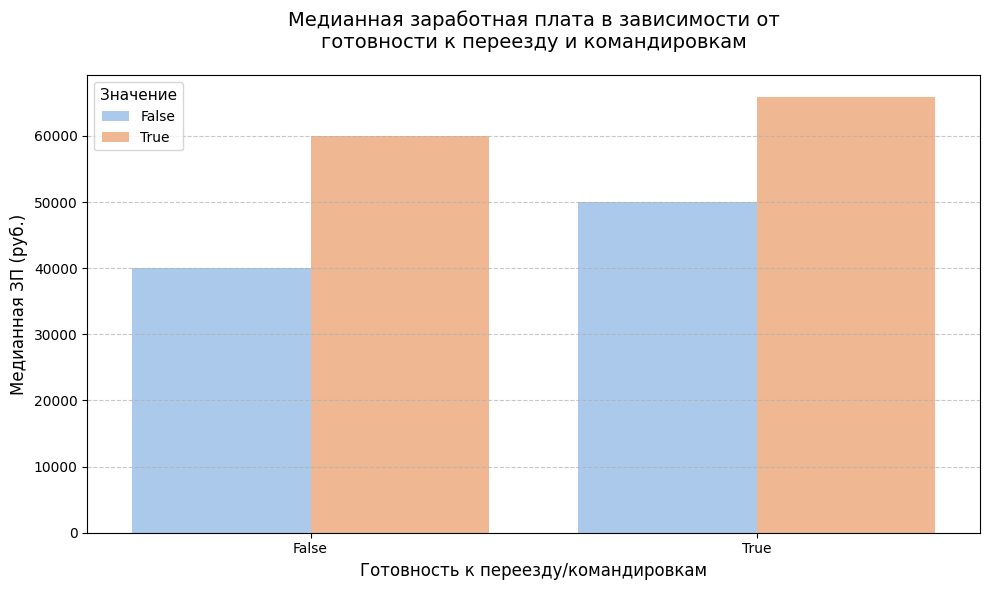

In [33]:
median_salary = (
    df.groupby(['Готовность к переезду', 'Готовность к командировкам'])['ЗП (руб)']
    .median()
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=median_salary,
    x='Готовность к переезду',
    y='ЗП (руб)',
    hue='Готовность к командировкам',
    palette='pastel'
)
plt.title('Медианная заработная плата в зависимости от\nготовности к переезду и командировкам', fontsize=14, pad=20)
plt.xlabel('Готовность к переезду/командировкам', fontsize=12)
plt.ylabel('Медианная ЗП (руб.)', fontsize=12)
plt.legend(title='Значение', title_fontsize=11, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [34]:
filtered = df[
    (df['Готовность к переезду'] == True) &
    (df['Готовность к командировкам'] == True)
]

median_salary = filtered['ЗП (руб)'].median()
print(f"Медианная заработная плата соискателей, готовых и к переезду, и к командировкам: {median_salary:,.0f} руб.")


Медианная заработная плата соискателей, готовых и к переезду, и к командировкам: 65,849 руб.


Готовность к переезду положительно отражается на медианной зарплате.  
   Соискатели, готовые к переезду, в среднем указывают более высокую медианную желаемую заработную плату, чем те, кто не готов.

Готовность к командировкам также связана с более высокой медианной зарплатой.  
   В каждой группе (готов/не готов к переезду) медианное значение заметно выше у тех, кто готов ездить в командировки.

Максимальная медианная ЗП — у группы, где обе готовности положительные (True/True).  
   Это логично — дополнительная мобильность и гибкость ценится работодателями, что отражается на ожиданиях кандидатов по зарплате.

Как готовность к переезду, так и готовность к командировкам заметно повышает медианную желаемую зарплату.

7. Постройте сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице постройте **тепловую карту**. Проанализируйте тепловую карту, сравнив показатели внутри групп.

In [35]:
pivot = df.pivot_table(
    index='Образование',
    columns='Возраст',
    values='ЗП (руб)',
    aggfunc='median',
    fill_value=0
)
fig = px.imshow(
    pivot,
    aspect='auto',
    color_continuous_scale='greens',
    title='Медианная з/п по образованию и возрасту'
)
fig.show()

Высшее образование заметно ассоциируется с более высокими медианными зарплатами по сравнению с остальными категориями образования практически во всех возрастах. Самые тёмные участки (насыщенный зелёный цвет) находятся именно в строке «высшее», особенно в возрасте от 25 до примерно 55 лет.

Уровень медианной зарплаты для кандидатов с неоконченным высшим ниже, но чётко выше, чем для «среднего» и «среднего специального» образования, что подчёркивает значимость даже неполного высшего.

В категориях «среднее» и «среднее специальное» ярко выражены светлые зоны — это самые низкие (минимальные) медианные значения заработной платы.

Возраст: практически во всех группах образование/возраст медианная зарплата растёт от молодых лет к 35-45 годам, затем достигает плато и может слегка снижаться после 50-60 лет. Это отражается в изменении интенсивности окраски по оси X.

В старших возрастных группах (старше 60-70 лет) и экстремально молодых часто возникает «пустота» или светлые участки — вероятнее всего, из-за отсутствия данных или очень малых выборок.
  
Высшее образование и зрелый возраст (25–50 лет) — залог более высоких медианных ожиданий по зарплате. Чем ниже образование, тем слабее влияние возраста и меньше разброс по медианной ЗП. И образование, и возраст — безусловно важные факторы уровня желаемой заработной платы.

8. Постройте **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**). Опыт работы переведите из месяцев в года, чтобы признаки были в едином масштабе. Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100). Данная прямая соответствует значениям, когда опыт работы равен возрасту человека. Точки, лежащие на этой прямой и выше нее - аномалии в наших данных (опыт работы больше либо равен возрасту соискателя)

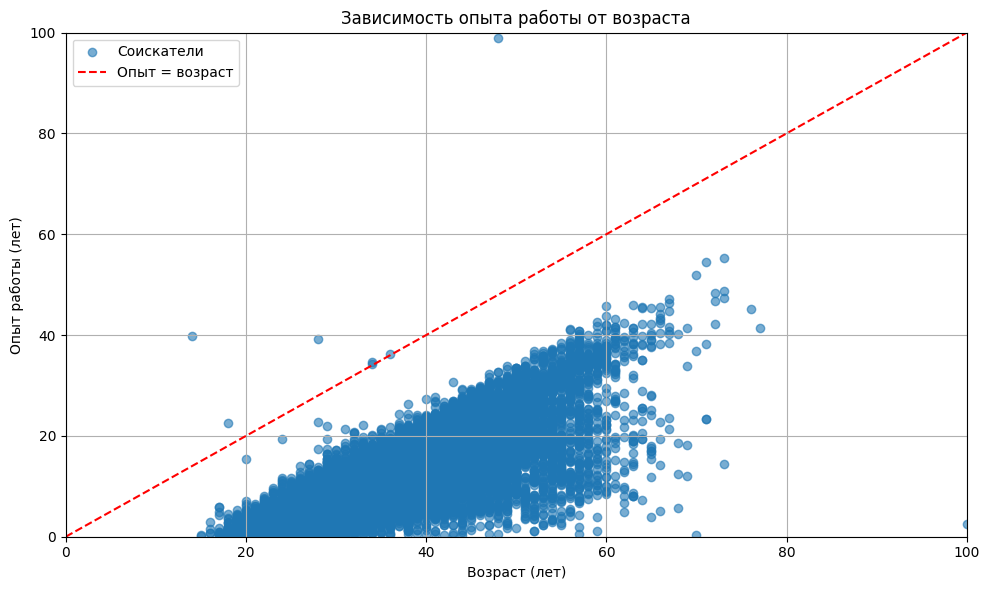

In [36]:
df['Опыт_годы'] = df['Опыт работы (месяц)'] / 12
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(df['Возраст'], df['Опыт_годы'], alpha=0.6, label='Соискатели')

plt.plot([0, 100], [0, 100], 'r--', label='Опыт = возраст')

plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel('Возраст (лет)')
plt.ylabel('Опыт работы (лет)')
plt.title('Зависимость опыта работы от возраста')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [37]:
anomalies = df[df['Опыт_годы'] > df['Возраст']]
count_anomalies = anomalies.shape[0]
print(f'Количество наблюдений, где опыт (лет) больше возраста: {count_anomalies}')


Количество наблюдений, где опыт (лет) больше возраста: 7


На диаграмме видно, что подавляющее большинство точек (соискателей) расположено ниже красной линии y=x (опыт работы < возраст), что логично: невозможно, чтобы человек имел больше лет трудового стажа, чем возраст.

Однако единичные точки всё же находятся строго выше этой линии. Несколько наблюдений, где опыт работы составляет 40+ лет при возрасте около 30–40 лет, и особенно один яркий выброс около (40, 95) — такого быть не может.

Строго выше прямой лежит небольшое количество точек. Обычно это единичные ошибки в заполнении данных или технические проблемы при сборе анкет.

**Дополнительные баллы**

Для получения 2 дополнительных баллов по разведывательному анализу постройте еще два любых содержательных графика или диаграммы, которые помогут проиллюстрировать влияние признаков/взаимосвязь между признаками/распределения признаков. Приведите выводы по ним. Желательно, чтобы в анализе участвовали признаки, которые мы создавали ранее в разделе "Преобразование данных".


# Очистка данных

1. Начнем с дубликатов в наших данных. Найдите **полные дубликаты** в таблице с резюме и удалите их.

In [38]:
duplicates = df[df.duplicated()]
print(f'Найдено полных дубликатов: {duplicates.shape[0]}')
df_cleaned = df.drop_duplicates().copy()
print(f'Размер таблицы после очистки: {df_cleaned.shape}')

Найдено полных дубликатов: 161
Размер таблицы после очистки: (44583, 24)


2. Займемся пропусками. Выведите информацию **о числе пропусков** в столбцах.

In [39]:
df.isna().sum()

,0
Ищет работу на должность:,0
Последнее/нынешнее место работы,1
Последняя/нынешняя должность,2
Обновление резюме,0
Авто,0
Образование,0
Пол,0
Возраст,0
Опыт работы (месяц),170
Город,0


In [53]:
null_df = df.isnull().sum()
display(null_df[null_df > 0])

,0
Опыт_годы,168


3. Итак, у нас есть пропуски в 3ех столбцах: **"Опыт работы (месяц)"**, **"Последнее/нынешнее место работы"**, **"Последняя/нынешняя должность"**. Поступим следующим образом: удалите строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполните **медианным** значением.

In [40]:
cols_to_drop_na = ['Последнее/нынешнее место работы',
                   'Последняя/нынешняя должность']

df = df.dropna(subset=cols_to_drop_na)
col_exp = 'Опыт работы (месяц)'
df[col_exp] = pd.to_numeric(df[col_exp], errors='coerce')
median_exp = df[col_exp].median()
df[col_exp] = df[col_exp].fillna(median_exp)

In [41]:
col_exp = 'Опыт работы (месяц)'
mean_exp = df[col_exp].mean()
mean_exp_rounded = round(mean_exp)
mean_exp_rounded


114

4. Мы добрались до ликвидации выбросов. Сначала очистим данные вручную. Удалите резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [42]:
salary_col = 'ЗП (руб)'
n_before = len(df)
df[salary_col] = pd.to_numeric(df[salary_col], errors='coerce')

df = df[(df[salary_col] >= 1000) & (df[salary_col] <= 1000000)]
n_after = len(df)
n_outliers = n_before - n_after
print(n_outliers)

89


5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдите такие резюме и удалите их из данных


In [43]:
outliers = df[df['Опыт работы (месяц)']/12 >= df['Возраст']]
df = df.drop(outliers.index)
print(outliers.shape[0])

7


6. В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуйте построить распределение признака в **логарифмическом масштабе**. Добавьте к графику линии, отображающие **среднее и границы интервала метода трех сигм**. Напомним, сделать это можно с помощью метода axvline. Например, для построение линии среднего будет иметь вид:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

В какую сторону асимметрично логарифмическое распределение? Напишите об этом в комментарии к графику.
Найдите выбросы с помощью метода z-отклонения и удалите их из данных, используйте логарифмический масштаб. Давайте сделаем послабление на **1 сигму** (возьмите 4 сигмы) в **правую сторону**.

Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?

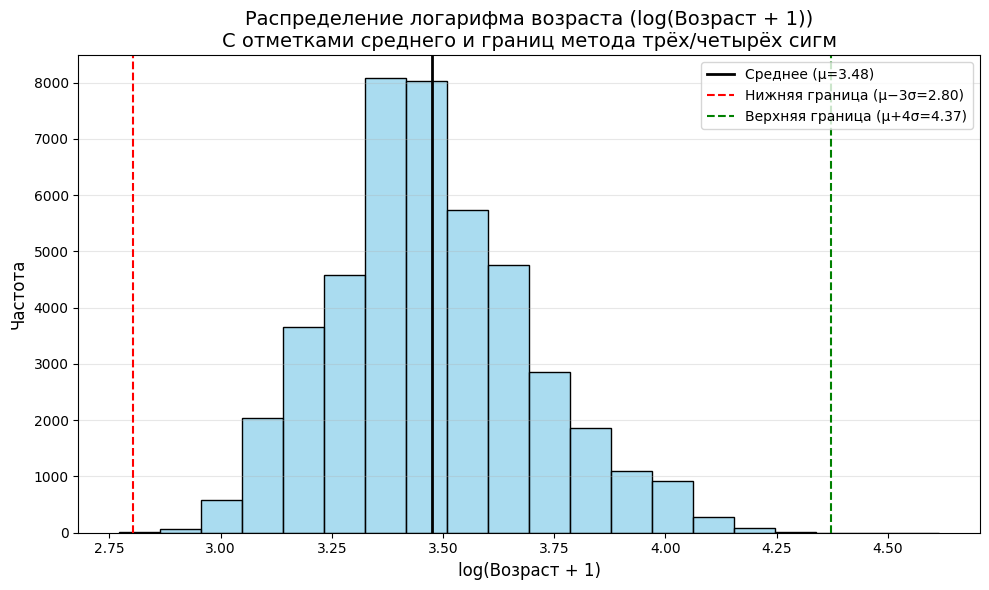

АНАЛИЗ ВЫБРОСОВ ПО МЕТОДУ Z‑ОТКЛОНЕНИЯ (ЛОГАРИФМИЧЕСКАЯ ШКАЛА)
Среднее log: 3.476
Стандартное отклонение log(Возраст+1): 0.224
Нижняя граница (μ − 3σ): 2.804
Верхняя граница (μ + 4σ): 4.373

Количество выбросов: 3
Выбросы (исходный возраст):
0     15
1     15
2    100
Name: Возраст, dtype: int64


In [49]:
ages = df['Возраст'].dropna()

log_ages = np.log(ages + 1)

mean_log = log_ages.mean()
std_log = log_ages.std()

lower_bound_log = mean_log - 3 * std_log
upper_bound_log = mean_log + 4 * std_log

z_scores = np.abs((log_ages - mean_log) / std_log)
outliers_mask = (z_scores > 3) & (log_ages < mean_log) | (z_scores > 4) & (log_ages > mean_log)
outliers_log = log_ages[outliers_mask]
outlers_orig = ages[outliers_mask]

fig, ax = plt.subplots(figsize=(10, 6))

histplot = sns.histplot(log_ages, bins=20, kde=False, ax=ax, color='skyblue', alpha=0.7)

ax.axvline(mean_log, color='k', lw=2, label=f'Среднее (μ={mean_log:.2f})')
ax.axvline(lower_bound_log, color='r', lw=1.5, linestyle='--', label=f'Нижняя граница (μ−3σ={lower_bound_log:.2f})')
ax.axvline(upper_bound_log, color='g', lw=1.5, linestyle='--', label=f'Верхняя граница (μ+4σ={upper_bound_log:.2f})')

ax.set_title('Распределение логарифма возраста (log(Возраст + 1))\nС отметками среднего и границ метода трёх/четырёх сигм', fontsize=14)
ax.set_xlabel('log(Возраст + 1)', fontsize=12)
ax.set_ylabel('Частота', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()

print("=" * 60)
print("АНАЛИЗ ВЫБРОСОВ ПО МЕТОДУ Z‑ОТКЛОНЕНИЯ (ЛОГАРИФМИЧЕСКАЯ ШКАЛА)")
print("=" * 60)

print(f"Среднее log: {mean_log:.3f}")
print(f"Стандартное отклонение log(Возраст+1): {std_log:.3f}")
print(f"Нижняя граница (μ − 3σ): {lower_bound_log:.3f}")
print(f"Верхняя граница (μ + 4σ): {upper_bound_log:.3f}")


print(f"\nКоличество выбросов: {len(outlers_orig)}")
if len(outlers_orig) > 0:
    print("Выбросы (исходный возраст):")
    print(outlers_orig.sort_values().reset_index(drop=True))
else:
    print("Выбросов не обнаружено.")


На графике видно, что правый "хвост" распределения шире — встречаются люди с более высоким возрастом, иногда сильно выше среднего. В логарифмической шкале распределение асимметрично вправо (положительная асимметрия, или правостороннее).

После применения критерия 4 сигм вправо и 3 сигм влево выбросы определены как наблюдения, выходящие за границы (μ + 4σ = 4.373, μ – 3σ = 2.804).

Выбросы по возрасту приходятся на значения 15 и 100 лет.

In [51]:
log_ages = np.log(ages + 1)
mean_log = log_ages.mean()
std_log = log_ages.std()
lower_bound = mean_log - 3 * std_log
upper_bound = mean_log + 4 * std_log
outliers_mask = (log_ages < lower_bound) | (log_ages > upper_bound)
df_clean = df.drop(ages[outliers_mask].index)